In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def order_points(pts):
    """
    4개의 점을 [좌상, 우상, 우하, 좌하] 순서로 정렬하는 함수

    Parameters
    ----------
    pts : array-like, shape (4, 2)
        4개의 2D 점 좌표

    Returns
    -------
    rect : np.ndarray, shape (4, 2), dtype=float32
        정렬된 4개 점
    """
    pts = np.asarray(pts, dtype=np.float32)

    # 각 점의 x+y 값
    s = pts.sum(axis=1)

    # 각 점의 x-y 값
    diff = np.diff(pts, axis=1).reshape(-1)

    # x+y가 가장 작은 점 = 좌상단
    top_left = pts[np.argmin(s)]

    # x+y가 가장 큰 점 = 우하단
    bottom_right = pts[np.argmax(s)]

    # x-y가 가장 작은 점 = 우상단
    top_right = pts[np.argmin(diff)]

    # x-y가 가장 큰 점 = 좌하단
    bottom_left = pts[np.argmax(diff)]

    rect = np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)
    return rect

In [3]:
def detect_marker_by_orb(reference_img, scene_img, min_matches=12, ratio_thresh=0.75):
    """
    기준 마커 이미지를 이용해 입력 사진(scene_img) 속에서
    마커의 위치(4개 꼭짓점)를 찾는 함수

    Parameters
    ----------
    reference_img : np.ndarray
        기준 마커 이미지 (정면에서 찍은 이미지, BGR)
    scene_img : np.ndarray
        입력 사진 (마커가 포함된 실제 사진, BGR)
    min_matches : int
        좋은 매칭의 최소 개수
    ratio_thresh : float
        Lowe's ratio test 기준값

    Returns
    -------
    scene_corners : np.ndarray, shape (4, 2)
        입력 사진 속에서 검출된 마커의 4개 꼭짓점
    match_vis : np.ndarray
        특징점 매칭 시각화 이미지
    good_matches : list
        필터링된 좋은 매칭 리스트
    H_ref_to_scene : np.ndarray, shape (3, 3)
        기준 마커 -> 입력 사진으로 가는 homography
    """
    # 컬러 이미지를 그레이스케일로 변환
    ref_gray = cv2.cvtColor(reference_img, cv2.COLOR_BGR2GRAY)
    scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

    # ORB 특징점 추출기 생성
    # nfeatures를 크게 잡아두면 특징점을 더 많이 찾습니다.
    orb = cv2.ORB_create(nfeatures=3000)

    # 기준 이미지와 입력 이미지의 특징점 / 기술자(descriptor) 추출
    kp1, des1 = orb.detectAndCompute(ref_gray, None)
    kp2, des2 = orb.detectAndCompute(scene_gray, None)

    if des1 is None or len(kp1) < 4:
        raise RuntimeError("기준 마커 이미지에서 특징점을 충분히 찾지 못했습니다.")
    if des2 is None or len(kp2) < 4:
        raise RuntimeError("입력 사진에서 특징점을 충분히 찾지 못했습니다.")

    # ORB는 Hamming distance를 사용합니다.
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

    # knnMatch로 가장 가까운 2개 후보를 찾습니다.
    matches = bf.knnMatch(des1, des2, k=2)

    # Lowe's ratio test
    # 첫 번째 후보가 두 번째 후보보다 충분히 더 좋을 때만 좋은 매칭으로 인정
    good_matches = []
    for pair in matches:
        # 혹시 2개가 안 나온 경우 방어
        if len(pair) < 2:
            continue

        m, n = pair
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)

    if len(good_matches) < min_matches:
        raise RuntimeError(
            f"좋은 매칭 수가 부족합니다. "
            f"현재={len(good_matches)}, 최소 필요={min_matches}"
        )

    # 좋은 매칭에 해당하는 좌표 추출
    ref_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    scene_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # RANSAC을 이용해 homography 계산
    H_ref_to_scene, mask = cv2.findHomography(ref_pts, scene_pts, cv2.RANSAC, 5.0)

    if H_ref_to_scene is None:
        raise RuntimeError("Homography 계산에 실패했습니다.")

    # 기준 마커 이미지의 4개 모서리 정의
    h_ref, w_ref = ref_gray.shape[:2]
    ref_corners = np.array([
        [0, 0],              # 좌상
        [w_ref - 1, 0],      # 우상
        [w_ref - 1, h_ref - 1],  # 우하
        [0, h_ref - 1]       # 좌하
    ], dtype=np.float32).reshape(-1, 1, 2)

    # 기준 이미지의 4개 모서리를 입력 사진 좌표계로 변환
    scene_corners = cv2.perspectiveTransform(ref_corners, H_ref_to_scene).reshape(4, 2)

    # 점 순서를 일정하게 정렬
    scene_corners = order_points(scene_corners)

    # 매칭 시각화
    match_vis = cv2.drawMatches(
        reference_img, kp1,
        scene_img, kp2,
        good_matches[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return scene_corners, match_vis, good_matches, H_ref_to_scene

In [4]:
def warp_from_detected_marker(scene_img, scene_corners, output_size=(1200, 1200)):
    """
    입력 사진 속에서 검출된 마커의 4개 꼭짓점을 기준으로
    이미지를 투시변환하는 함수

    Parameters
    ----------
    scene_img : np.ndarray
        입력 사진 (BGR)
    scene_corners : np.ndarray, shape (4, 2)
        입력 사진에서 검출된 마커의 4개 꼭짓점
    output_size : tuple
        결과 이미지 크기 (width, height)

    Returns
    -------
    warped : np.ndarray
        투시변환된 결과 이미지
    H_scene_to_dst : np.ndarray, shape (3, 3)
        입력 사진 -> 출력 평면으로 가는 homography
    src_pts : np.ndarray
        입력 사진에서 사용한 4개 점
    dst_pts : np.ndarray
        출력 평면의 4개 점
    """
    # 4개 점 순서 보정
    src_pts = order_points(scene_corners)

    out_w, out_h = output_size

    # 결과 이미지에서의 목표 좌표
    dst_pts = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1]
    ], dtype=np.float32)

    # 투시변환 행렬 계산
    H_scene_to_dst = cv2.getPerspectiveTransform(src_pts, dst_pts)

    # 실제 투시변환 수행
    warped = cv2.warpPerspective(scene_img, H_scene_to_dst, (out_w, out_h))

    return warped, H_scene_to_dst, src_pts, dst_pts

In [5]:
def run_reference_marker_pipeline(
    reference_path,
    image_path,
    output_dir="outputs",
    output_size=(1200, 1200),
    min_matches=12,
    ratio_thresh=0.75
):
    """
    실제 사용하는 기준 마커 이미지를 template로 사용하여
    입력 사진에서 마커를 찾고,
    그 마커를 기준으로 투시변환까지 수행하는 전체 파이프라인

    Parameters
    ----------
    reference_path : str or Path
        기준 마커 이미지 파일 경로
    image_path : str or Path
        입력 사진 파일 경로
    output_dir : str or Path
        결과 저장 폴더
    output_size : tuple
        투시변환 결과 이미지 크기 (width, height)
    min_matches : int
        ORB 좋은 매칭 최소 개수
    ratio_thresh : float
        ORB ratio test 임계값

    Returns
    -------
    result : dict
        처리 결과를 담은 딕셔너리
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    # 이미지 읽기
    reference_img = cv2.imread(str(reference_path))
    scene_img = cv2.imread(str(image_path))

    if reference_img is None:
        raise FileNotFoundError(f"기준 마커 이미지를 찾을 수 없습니다: {reference_path}")
    if scene_img is None:
        raise FileNotFoundError(f"입력 이미지를 찾을 수 없습니다: {image_path}")

    # -----------------------------------------------------
    # 1) 기준 마커를 입력 사진에서 찾기
    # -----------------------------------------------------
    scene_corners, match_vis, good_matches, H_ref_to_scene = detect_marker_by_orb(
        reference_img=reference_img,
        scene_img=scene_img,
        min_matches=min_matches,
        ratio_thresh=ratio_thresh
    )

    # -----------------------------------------------------
    # 2) 입력 사진에 검출된 마커 위치 그리기
    # -----------------------------------------------------
    debug_img = scene_img.copy()
    pts_int = scene_corners.astype(int)

    # 외곽 사각형 그리기
    for i in range(4):
        p1 = tuple(pts_int[i])
        p2 = tuple(pts_int[(i + 1) % 4])
        cv2.line(debug_img, p1, p2, (0, 255, 255), 4)

    # 각 꼭짓점 표시
    for i, pt in enumerate(pts_int):
        cv2.circle(debug_img, tuple(pt), 10, (0, 0, 255), -1)
        cv2.putText(
            debug_img, f"P{i}", tuple(pt + 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2, cv2.LINE_AA
        )

    # -----------------------------------------------------
    # 3) 검출된 마커 4점을 기준으로 투시변환
    # -----------------------------------------------------
    warped, H_scene_to_dst, src_pts, dst_pts = warp_from_detected_marker(
        scene_img=scene_img,
        scene_corners=scene_corners,
        output_size=output_size
    )

    # -----------------------------------------------------
    # 4) 결과 저장
    # -----------------------------------------------------
    stem = Path(image_path).stem

    match_path = output_dir / f"{stem}_matches.jpg"
    debug_path = output_dir / f"{stem}_marker_detected.jpg"
    warped_path = output_dir / f"{stem}_warped.jpg"

    cv2.imwrite(str(match_path), match_vis)
    cv2.imwrite(str(debug_path), debug_img)
    cv2.imwrite(str(warped_path), warped)

    # -----------------------------------------------------
    # 5) 화면 출력
    # -----------------------------------------------------
    plt.figure(figsize=(20, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"ORB Matches ({len(good_matches)})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.title("Detected Marker Region")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    plt.title("Warped Result")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # 6) 결과 반환
    # -----------------------------------------------------
    result = {
        "reference_path": str(reference_path),
        "image_path": str(image_path),
        "scene_corners": src_pts,
        "good_match_count": len(good_matches),
        "H_ref_to_scene": H_ref_to_scene,
        "H_scene_to_dst": H_scene_to_dst,
        "match_path": str(match_path),
        "debug_path": str(debug_path),
        "warped_path": str(warped_path),
        "warped": warped
    }

    return result

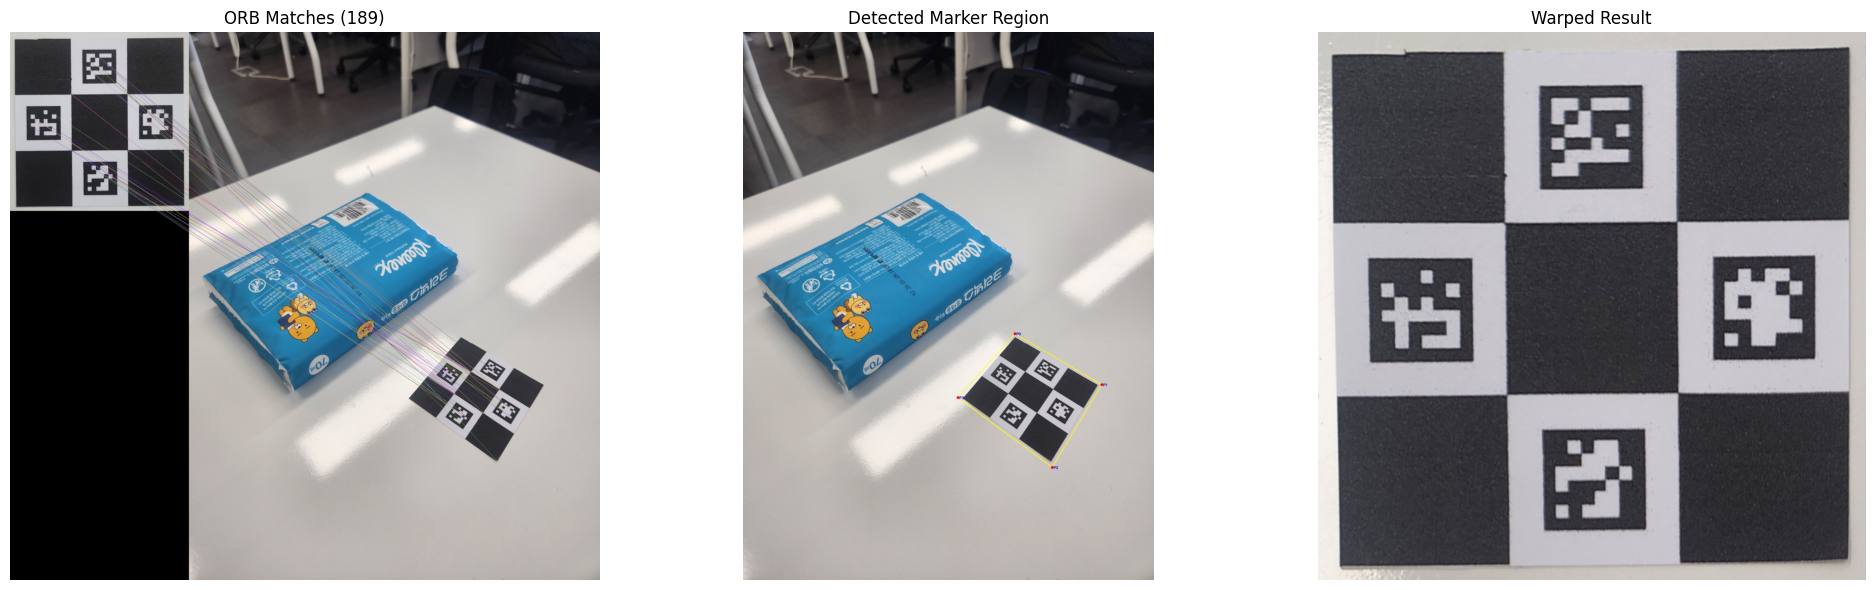

좋은 매칭 개수: 189
검출된 마커 꼭짓점:
 [[1985.9968 2202.7092]
 [2619.028  2574.1387]
 [2257.1438 3178.1685]
 [1569.2189 2668.5032]]
매칭 결과 저장: outputs\sample_with_marker_matches.jpg
검출 결과 저장: outputs\sample_with_marker_marker_detected.jpg
투시변환 결과 저장: outputs\sample_with_marker_warped.jpg


In [7]:
reference_path = "reference_marker.jpg"       # 실제 사용하는 마커를 정면으로 잘라 저장한 이미지
image_path = "sample_with_marker.jpg"         # 마커가 포함된 실제 촬영 사진

result = run_reference_marker_pipeline(
    reference_path=reference_path,
    image_path=image_path,
    output_dir="outputs",
    output_size=(1200, 1200),
    min_matches=12,
    ratio_thresh=0.75
)

print("좋은 매칭 개수:", result["good_match_count"])
print("검출된 마커 꼭짓점:\n", result["scene_corners"])
print("매칭 결과 저장:", result["match_path"])
print("검출 결과 저장:", result["debug_path"])
print("투시변환 결과 저장:", result["warped_path"])